In [ ]:
# ==============================================================================
# 1. DATA PREPROCESSING PIPELINE
# ==============================================================================
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

file_path = '/content/Dataset .csv'
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

noise_columns = ['Restaurant ID', 'Restaurant Name', 'Address', 'Rating text', 'Phone', 'Locality Verbose', 'Rating color', 'Votes']
df = df.drop(columns=[col for col in noise_columns if col in df.columns], errors='ignore')

if 'Aggregate rating' in df.columns:
    df = df[df['Aggregate rating'] != 0.0]
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]

crucial_cols = ['Aggregate rating', 'Cuisines', 'City', 'Latitude', 'Longitude']
df = df.dropna(subset=[col for col in crucial_cols if col in df.columns])

exchange_rates = {
    'Indian Rupees(Rs.)': 0.012, 'Dollar($)': 1.0, 'Pounds(£)': 1.25,
    'Rand(R)': 0.053, 'Emirati Diram(AED)': 0.27, 'Brazilian Real(R$)': 0.20,
    'NewZealand($)': 0.61, 'Turkish Lira(TL)': 0.032, 'Qatari Rial(QR)': 0.27,
    'Sri Lankan Rupee(LKR)': 0.0033, 'Indonesian Rupiah(IDR)': 0.000063,
    'Botswana Pula(P)': 0.073
}

if 'Average Cost for two' in df.columns and 'Currency' in df.columns:
    df['Cost in USD'] = df.apply(lambda row: round(row['Average Cost for two'] * exchange_rates.get(row['Currency'], 1), 2), axis=1)
    df = df.drop(columns=['Average Cost for two', 'Currency', 'Country Code'], errors='ignore')

if 'Cuisines' in df.columns:
    cuisine_target_means = df.groupby('Cuisines')['Aggregate rating'].mean()
    df['Cuisines_Encoded'] = df['Cuisines'].map(cuisine_target_means)
    df = df.drop(columns=['Cuisines'])

binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

le = LabelEncoder()
if 'City' in df.columns:
    df['City_Encoded'] = le.fit_transform(df['City'].astype(str))
    df = df.drop(columns=['City'])

if 'Locality' in df.columns:
    df['Locality_Encoded'] = le.fit_transform(df['Locality'].astype(str))
    df = df.drop(columns=['Locality'])

save_path = '/content/Fully_Encoded_Dataset_USD.csv'
df.to_csv(save_path, index=False)
print(f"Pipeline Complete! File saved to: {save_path}")

Pipeline Complete! File saved to: /content/Fully_Encoded_Dataset_USD.csv


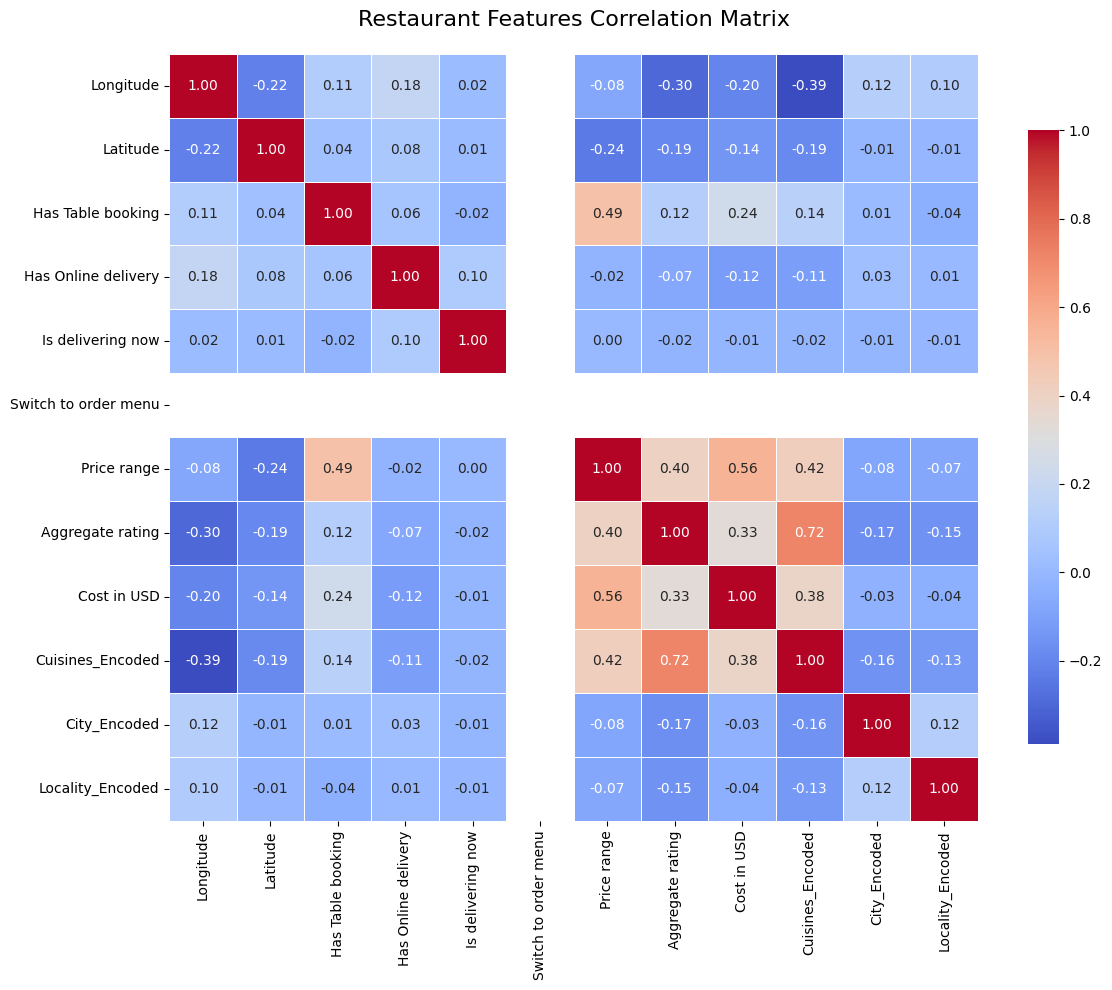

In [ ]:
# ==============================================================================
# 2. CORRELATION HEATMAP
# ==============================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the file we saved in Cell 1
df_encoded = pd.read_csv('/content/Fully_Encoded_Dataset_USD.csv')

# Calculate correlation
corr_matrix = df_encoded.corr()

# Draw the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Restaurant Features Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 3. MODEL TRAINING & EVALUATION (RANDOM FOREST)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the final dataset
df_ml = pd.read_csv('/content/Fully_Encoded_Dataset_USD.csv')

# Split into X (clues) and y (target rating)
X = df_ml.drop(columns=['Aggregate rating'])
y = df_ml['Aggregate rating']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
print("Training the Random Forest Model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Check the accuracy
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*40)
print("🎯 MODEL ACCURACY REPORT")
print("="*40)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared (Accuracy Score):     {r2:.4f}")
print("="*40)

# Print Feature Importance
print("\nTop 5 Most Important Factors:")
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importances.head(5).to_string(index=False))

Training the Random Forest Model...
🎯 MODEL ACCURACY REPORT
Root Mean Squared Error (RMSE): 0.3414
R-Squared (Accuracy Score):     0.6112

Top 5 Most Important Factors:
         Feature  Importance
Cuisines_Encoded    0.578780
        Latitude    0.142147
       Longitude    0.112074
     Cost in USD    0.063737
Locality_Encoded    0.059175


Loading datasets for comparison...


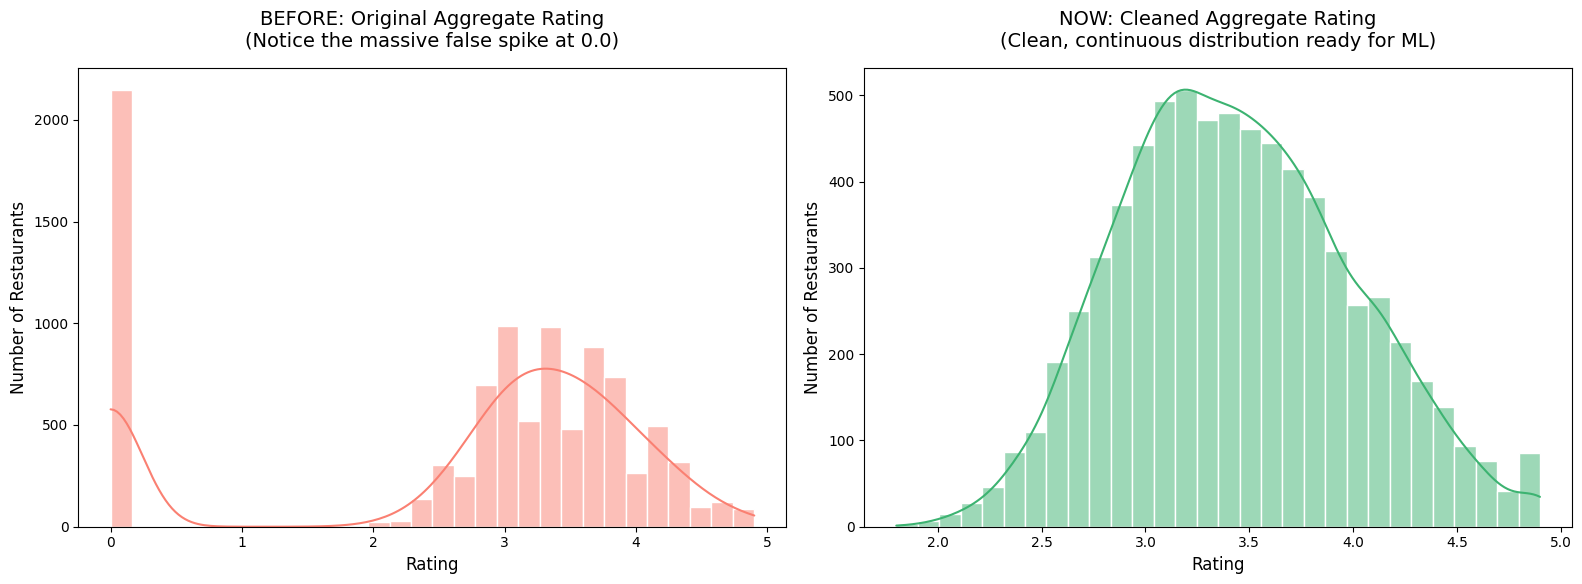

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading datasets for comparison...")
# Load both the original and the final cleaned datasets
df_original = pd.read_csv('/content/Dataset .csv')
df_cleaned = pd.read_csv('/content/Fully_Encoded_Dataset_USD.csv')

# Set up the visual canvas (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: BEFORE (Original Data)
# ==========================================
sns.histplot(
    df_original['Aggregate rating'],
    bins=30,
    kde=True,
    color='salmon',
    ax=axes[0]
)
axes[0].set_title('BEFORE: Original Aggregate Rating\n(Notice the massive false spike at 0.0)', fontsize=14, pad=15)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Number of Restaurants', fontsize=12)

# ==========================================
# PLOT 2: NOW (Cleaned Data)
# ==========================================
sns.histplot(
    df_cleaned['Aggregate rating'],
    bins=30,
    kde=True,
    color='mediumseagreen',
    ax=axes[1]
)
axes[1].set_title('NOW: Cleaned Aggregate Rating\n(Clean, continuous distribution ready for ML)', fontsize=14, pad=15)
axes[1].set_xlabel('Rating', fontsize=12)
axes[1].set_ylabel('Number of Restaurants', fontsize=12)

# Display the charts
plt.tight_layout()
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files

# Load data
df = pd.read_csv('/content/Fully_Encoded_Dataset_USD.csv')
X = df.drop(columns=['Aggregate rating'])
y = df['Aggregate rating']

# 1. SPLIT FIRST (Crucial to prevent Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# The 'Cuisines' column was already processed and dropped in the previous pipeline.
# 'Cuisines_Encoded' is already present in X_train and X_test.
# Removing redundant target encoding steps.

# 3. GEOSPATIAL SCALING & CLUSTERING
scaler = StandardScaler()
X_train_coords = scaler.fit_transform(X_train[['Latitude', 'Longitude']])
X_test_coords = scaler.transform(X_test[['Latitude', 'Longitude']])

kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
X_train['Geo_Cluster'] = kmeans.fit_predict(X_train_coords)
X_test['Geo_Cluster'] = kmeans.predict(X_test_coords)

# 4. RANDOMIZED SEARCH (Fast & Robust)
xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1)
params = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'reg_alpha': [0.1, 1.0],
    'reg_lambda': [0.1, 1.0]
}

search = RandomizedSearchCV(xgb, params, n_iter=10, cv=3, scoring='r2', random_state=42)
search.fit(X_train, y_train)

# 5. SAVE FOR PRODUCTION
joblib.dump(search.best_estimator_, '/content/advanced_xgb_model.joblib')
joblib.dump(kmeans, '/content/kmeans_hotspot_model.joblib')
joblib.dump(scaler, '/content/gps_scaler.joblib')
files.download('/content/advanced_xgb_model.joblib')
files.download('/content/kmeans_hotspot_model.joblib')
files.download('/content/gps_scaler.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>